<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.


## Demo: How to work with database


Download the database file.


In [1]:
#!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [2]:
# !pip install pandas 
# !pip install matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [4]:
# Read the CSV file
df = pd.read_csv('survey_sample.csv')

# Display the first few rows of the data
df.head()

,index,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,36662,36663,I am a developer by profession,18-24 years old,I prefer not to say,NaN,Apples,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;On the job training;Sch...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN,NaN
1,36720,36721,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",On the job training;Other online resources (e....,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,84851.0,NaN
2,30718,30719,"I am not primarily a developer, but I write co...",25-34 years old,"Employed, full-time",Remote,Apples,Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",On the job training;Other online resources (e....,...,17.0,18.0,20.0,10.0,5.0,2.0,Appropriate in length,Easy,80000.0,7.0
3,17353,17354,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Other online resources ...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,75184.0,NaN
4,39838,39839,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","School (i.e., University, College, etc);Friend...",...,20.0,25.0,20.0,25.0,0.0,0.0,Appropriate in length,Easy,332712.0,9.0


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [5]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey_data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)

# Close the connection
conn.close()

**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [6]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey_data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)

   index  ResponseId                                         MainBranch  \
0  36662       36663                     I am a developer by profession   
1  36720       36721                     I am a developer by profession   
2  30718       30719  I am not primarily a developer, but I write co...   
3  17353       17354                     I am a developer by profession   
4  39838       39839                     I am a developer by profession   

               Age                                         Employment  \
0  18-24 years old                                I prefer not to say   
1  25-34 years old                                Employed, full-time   
2  25-34 years old                                Employed, full-time   
3  35-44 years old  Independent contractor, freelancer, or self-em...   
4  35-44 years old                                Employed, full-time   

                             RemoteWork   Check  \
0                                  None  Apples   
1  Hybri

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [7]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()

,COUNT(*)
0,1000


## Demo: Listing All Tables


To view the names of all tables in the database:


In [8]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)

,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [9]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)

,Age,count
0,18-24 years old,223
1,25-34 years old,343
2,35-44 years old,226
3,45-54 years old,107
4,55-64 years old,38
5,65 years or older,13
6,Prefer not to say,7
7,Under 18 years old,43


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [10]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])

CREATE TABLE "main" (
"index" INTEGER,
  "ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWan

## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


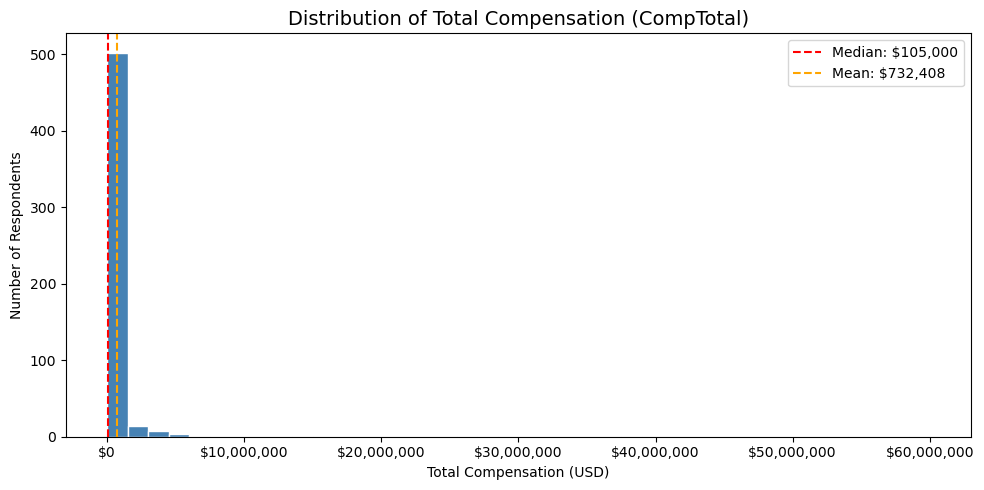

count    5.390000e+02
mean     2.569828e+07
std      4.333613e+08
min      0.000000e+00
25%      5.500000e+04
50%      1.056000e+05
75%      2.135000e+05
max      9.600000e+09
Name: CompTotal, dtype: float64


In [11]:
# Fetch CompTotal from the database
QUERY = "SELECT CompTotal FROM main WHERE CompTotal IS NOT NULL"
df_comp = pd.read_sql_query(QUERY, conn)

# Cap at 99th percentile to reduce the effect of extreme outliers
cap = df_comp['CompTotal'].quantile(0.99)
df_comp_capped = df_comp[df_comp['CompTotal'] <= cap]

plt.figure(figsize=(10, 5))
plt.hist(df_comp_capped['CompTotal'], bins=40, color='steelblue', edgecolor='white')
plt.title('Distribution of Total Compensation (CompTotal)', fontsize=14)
plt.xlabel('Total Compensation (USD)')
plt.ylabel('Number of Respondents')
plt.axvline(df_comp_capped['CompTotal'].median(), color='red',
            linestyle='--', label=f"Median: ${df_comp_capped['CompTotal'].median():,.0f}")
plt.axvline(df_comp_capped['CompTotal'].mean(), color='orange',
            linestyle='--', label=f"Mean: ${df_comp_capped['CompTotal'].mean():,.0f}")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend()
plt.tight_layout()
plt.show()

print(df_comp['CompTotal'].describe())

**Box Plots**

Plot a box plot of Age.


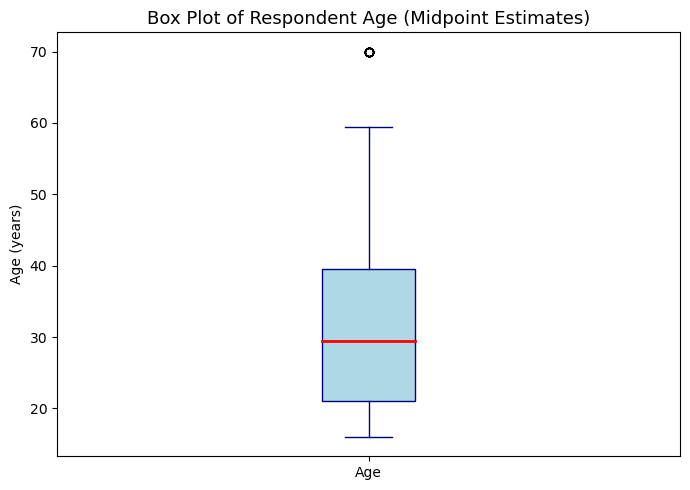

Age group distribution:
               Age  count
   18-24 years old    223
   25-34 years old    343
   35-44 years old    226
   45-54 years old    107
   55-64 years old     38
 65 years or older     13
Under 18 years old     43


In [12]:
# Fetch Age counts from the database
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
WHERE Age IS NOT NULL AND Age != 'Prefer not to say'
GROUP BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)

# Map each age group to its numeric midpoint
age_midpoint = {
    'Under 18 years old' : 16,
    '18-24 years old'    : 21,
    '25-34 years old'    : 29.5,
    '35-44 years old'    : 39.5,
    '45-54 years old'    : 49.5,
    '55-64 years old'    : 59.5,
    '65 years or older'  : 70
}

# Reconstruct an approximate numeric age series from group counts
age_values = []
for _, row in df_age.iterrows():
    midpt = age_midpoint.get(row['Age'])
    if midpt is not None:
        age_values.extend([midpt] * int(row['count']))

plt.figure(figsize=(7, 5))
plt.boxplot(age_values, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='navy'),
            capprops=dict(color='navy'))
plt.title('Box Plot of Respondent Age (Midpoint Estimates)', fontsize=13)
plt.ylabel('Age (years)')
plt.xticks([1], ['Age'])
plt.tight_layout()
plt.show()

print("Age group distribution:")
print(df_age.to_string(index=False))

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


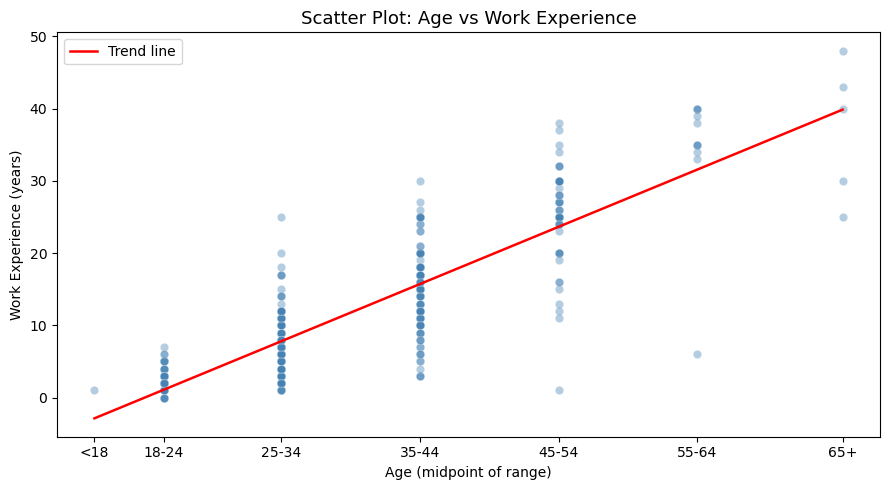

In [13]:
# Fetch Age and WorkExp from the database
QUERY = """
SELECT Age, WorkExp
FROM main
WHERE Age IS NOT NULL
  AND Age != 'Prefer not to say'
  AND WorkExp IS NOT NULL
"""
df_scatter = pd.read_sql_query(QUERY, conn)

# Map age groups to midpoint values
age_midpoint = {
    'Under 18 years old' : 16,
    '18-24 years old'    : 21,
    '25-34 years old'    : 29.5,
    '35-44 years old'    : 39.5,
    '45-54 years old'    : 49.5,
    '55-64 years old'    : 59.5,
    '65 years or older'  : 70
}
df_scatter['Age_Num'] = df_scatter['Age'].map(age_midpoint)

plt.figure(figsize=(9, 5))
plt.scatter(df_scatter['Age_Num'], df_scatter['WorkExp'],
            alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.3)

# Trend line
m, b = np.polyfit(df_scatter['Age_Num'], df_scatter['WorkExp'], 1)
x_range = np.linspace(df_scatter['Age_Num'].min(), df_scatter['Age_Num'].max(), 100)
plt.plot(x_range, m * x_range + b, color='red', linewidth=1.8, label='Trend line')

plt.title('Scatter Plot: Age vs Work Experience', fontsize=13)
plt.xlabel('Age (midpoint of range)')
plt.ylabel('Work Experience (years)')
plt.xticks([16, 21, 29.5, 39.5, 49.5, 59.5, 70],
           ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+'])
plt.legend()
plt.tight_layout()
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


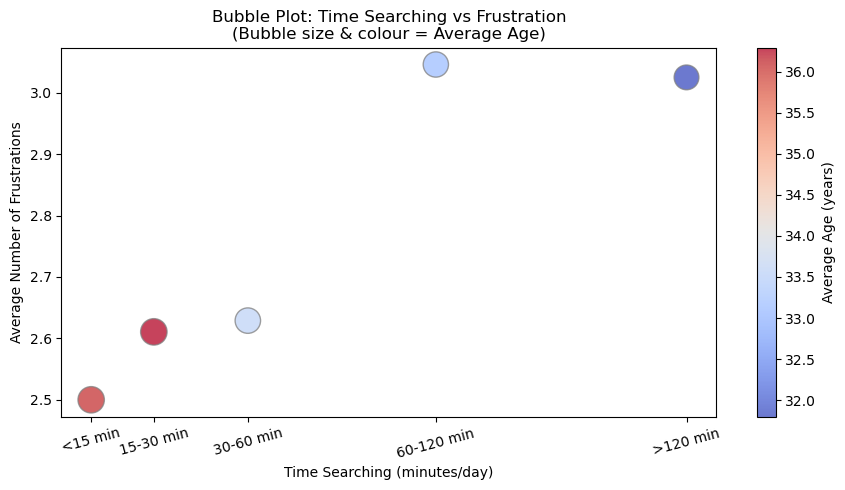

In [14]:
# Fetch TimeSearching, Frustration, and Age from the database
QUERY = """
SELECT TimeSearching, Frustration, Age
FROM main
WHERE TimeSearching IS NOT NULL
  AND Frustration IS NOT NULL
  AND Age IS NOT NULL
  AND Age != 'Prefer not to say'
"""
df_bubble = pd.read_sql_query(QUERY, conn)

# Map ordinal time labels to numeric midpoints (minutes/day)
time_map = {
    'Less than 15 minutes a day' :  7.5,
    '15-30 minutes a day'        : 22.5,
    '30-60 minutes a day'        : 45.0,
    '60-120 minutes a day'       : 90.0,
    'Over 120 minutes a day'     : 150.0
}
age_midpoint = {
    'Under 18 years old' : 16,
    '18-24 years old'    : 21,
    '25-34 years old'    : 29.5,
    '35-44 years old'    : 39.5,
    '45-54 years old'    : 49.5,
    '55-64 years old'    : 59.5,
    '65 years or older'  : 70
}

df_bubble['TimeSearching_Num'] = df_bubble['TimeSearching'].map(time_map)
df_bubble['Age_Num']           = df_bubble['Age'].map(age_midpoint)
# Use count of frustration items listed as a numeric proxy for y-axis
df_bubble['FrustrationCount'] = df_bubble['Frustration'].apply(
    lambda x: len(str(x).split(';')) if x != 'None of these' else 0
)

# Aggregate: average frustration count and age per TimeSearching group
agg = df_bubble.groupby('TimeSearching_Num').agg(
    AvgFrustration=('FrustrationCount', 'mean'),
    AvgAge=('Age_Num', 'mean'),
    Count=('FrustrationCount', 'count')
).reset_index()

plt.figure(figsize=(9, 5))
scatter = plt.scatter(
    agg['TimeSearching_Num'],
    agg['AvgFrustration'],
    s=agg['AvgAge'] * 10,        # bubble size = avg age (scaled)
    c=agg['AvgAge'],
    cmap='coolwarm',
    alpha=0.75,
    edgecolors='grey'
)
plt.colorbar(scatter, label='Average Age (years)')
plt.title('Bubble Plot: Time Searching vs Frustration\n(Bubble size & colour = Average Age)', fontsize=12)
plt.xlabel('Time Searching (minutes/day)')
plt.ylabel('Average Number of Frustrations')
plt.xticks(list(time_map.values()),
           ['<15 min', '15-30 min', '30-60 min', '60-120 min', '>120 min'], rotation=15)
plt.tight_layout()
plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


Top 5 Databases Respondents Want to Work With:
DatabaseWantToWorkWith
PostgreSQL    372
SQLite        233
MySQL         181
MongoDB       170
Redis         156
Name: count, dtype: int64


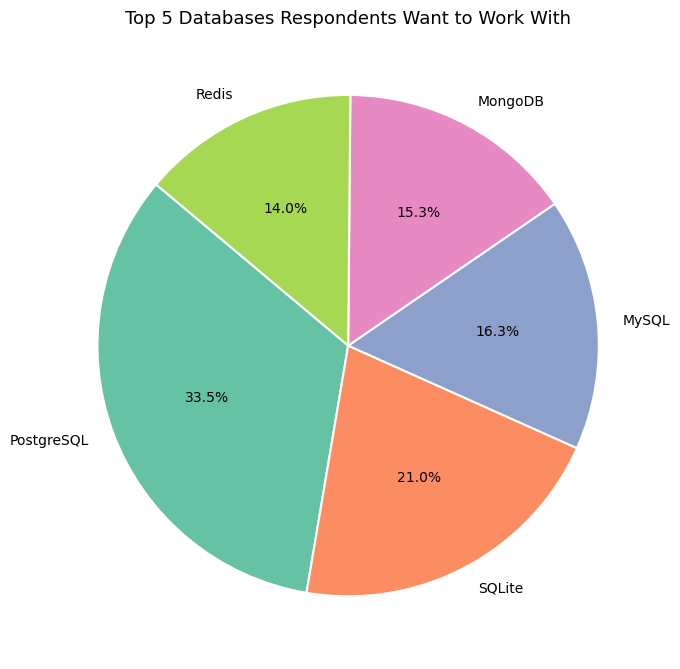

In [15]:
# Fetch DatabaseWantToWorkWith from the database
QUERY = "SELECT DatabaseWantToWorkWith FROM main WHERE DatabaseWantToWorkWith IS NOT NULL"
df_db = pd.read_sql_query(QUERY, conn)

# Split semicolon-separated entries and count individual databases
db_counts = (
    df_db['DatabaseWantToWorkWith']
    .str.split(';')
    .explode()
    .str.strip()
    .value_counts()
    .head(5)
)

print("Top 5 Databases Respondents Want to Work With:")
print(db_counts)

plt.figure(figsize=(7, 7))
plt.pie(
    db_counts.values,
    labels=db_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set2.colors[:5],
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
plt.title('Top 5 Databases Respondents Want to Work With', fontsize=13)
plt.tight_layout()
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


Median TimeSearching (25-34 age group): 45.0 min/day
Median TimeAnswering (25-34 age group): 22.5 min/day


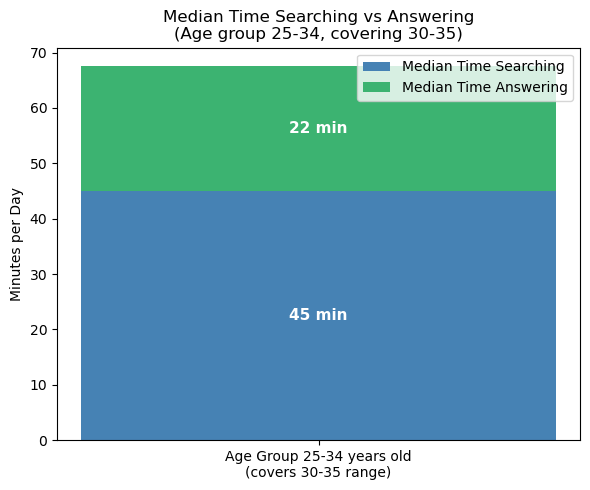

In [16]:
# Fetch TimeSearching and TimeAnswering for the 25-34 age group
# (closest available bracket covering the 30-35 range)
QUERY = """
SELECT TimeSearching, TimeAnswering
FROM main
WHERE Age = '25-34 years old'
  AND TimeSearching IS NOT NULL
  AND TimeAnswering IS NOT NULL
"""
df_time = pd.read_sql_query(QUERY, conn)

# Map ordinal labels to numeric midpoints (minutes/day)
time_map = {
    'Less than 15 minutes a day' :  7.5,
    '15-30 minutes a day'        : 22.5,
    '30-60 minutes a day'        : 45.0,
    '60-120 minutes a day'       : 90.0,
    'Over 120 minutes a day'     : 150.0
}
df_time['TimeSearching_Num'] = df_time['TimeSearching'].map(time_map)
df_time['TimeAnswering_Num'] = df_time['TimeAnswering'].map(time_map)

median_searching = df_time['TimeSearching_Num'].median()
median_answering = df_time['TimeAnswering_Num'].median()

print(f"Median TimeSearching (25-34 age group): {median_searching} min/day")
print(f"Median TimeAnswering (25-34 age group): {median_answering} min/day")

# Stacked bar chart
fig, ax = plt.subplots(figsize=(6, 5))
categories = ['Age Group 25-34 years old\n(covers 30-35 range)']
bars1 = ax.bar(categories, [median_searching], color='steelblue',  label='Median Time Searching')
bars2 = ax.bar(categories, [median_answering],  bottom=[median_searching],
               color='mediumseagreen', label='Median Time Answering')

# Add value labels
ax.text(0, median_searching / 2, f'{median_searching:.0f} min', ha='center', va='center',
        color='white', fontweight='bold', fontsize=11)
ax.text(0, median_searching + median_answering / 2, f'{median_answering:.0f} min',
        ha='center', va='center', color='white', fontweight='bold', fontsize=11)

ax.set_title('Median Time Searching vs Answering\n(Age group 25-34, covering 30-35)', fontsize=12)
ax.set_ylabel('Minutes per Day')
ax.legend()
plt.tight_layout()
plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


               Age     MedianComp  Age_Num
0  45-54 years old  185083.622951     49.5
1  55-64 years old  140333.333333     59.5


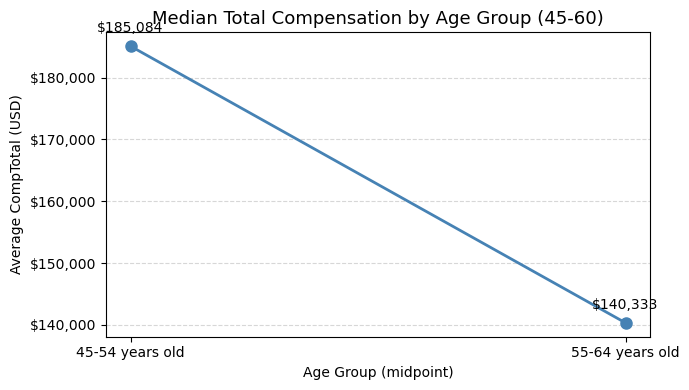

In [17]:
# The dataset uses age bands; the groups covering 45-60 are:
# '45-54 years old' and '55-64 years old'
QUERY = """
SELECT Age, AVG(CompTotal) as MedianComp
FROM (
    SELECT Age, CompTotal
    FROM main
    WHERE Age IN ('45-54 years old', '55-64 years old')
      AND CompTotal IS NOT NULL
      AND CompTotal <= 1000000
)
GROUP BY Age
ORDER BY Age
"""
df_line = pd.read_sql_query(QUERY, conn)

# Map labels to representative midpoints for the x-axis
age_midpoint = {'45-54 years old': 49.5, '55-64 years old': 59.5}
df_line['Age_Num'] = df_line['Age'].map(age_midpoint)

print(df_line)

plt.figure(figsize=(7, 4))
plt.plot(df_line['Age_Num'], df_line['MedianComp'],
         marker='o', color='steelblue', linewidth=2, markersize=8)

for _, row in df_line.iterrows():
    plt.annotate(f"${row['MedianComp']:,.0f}",
                 (row['Age_Num'], row['MedianComp']),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=10)

plt.title('Median Total Compensation by Age Group (45-60)', fontsize=13)
plt.xlabel('Age Group (midpoint)')
plt.ylabel('Average CompTotal (USD)')
plt.xticks([49.5, 59.5], ['45-54 years old', '55-64 years old'])
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


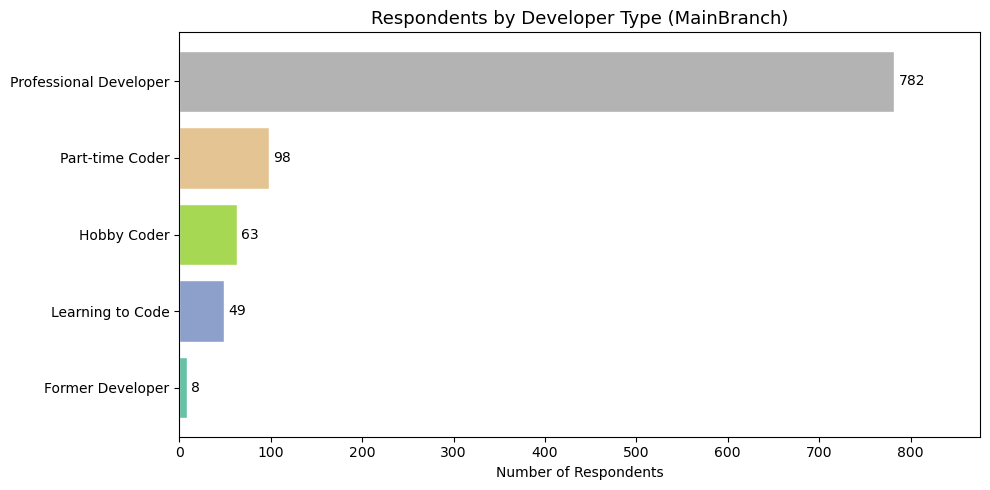

In [18]:
# Fetch MainBranch counts from the database
QUERY = """
SELECT MainBranch, COUNT(*) as count
FROM main
WHERE MainBranch IS NOT NULL
GROUP BY MainBranch
ORDER BY count ASC
"""
df_branch = pd.read_sql_query(QUERY, conn)

# Shorten long labels for readability
short_labels = {
    'I am a developer by profession':                                            'Professional Developer',
    'I am not primarily a developer, but I write code sometimes as part of my work/studies': 'Part-time Coder',
    'I code primarily as a hobby':                                               'Hobby Coder',
    'I am learning to code':                                                     'Learning to Code',
    'I used to be a developer by profession, but no longer am':                  'Former Developer'
}
df_branch['Label'] = df_branch['MainBranch'].replace(short_labels)

colors = plt.cm.Set2(np.linspace(0, 1, len(df_branch)))

plt.figure(figsize=(10, 5))
bars = plt.barh(df_branch['Label'], df_branch['count'], color=colors, edgecolor='white')

# Add count labels at the end of each bar
for bar, val in zip(bars, df_branch['count']):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
             str(val), va='center', fontsize=10)

plt.title('Respondents by Developer Type (MainBranch)', fontsize=13)
plt.xlabel('Number of Respondents')
plt.xlim(0, df_branch['count'].max() * 1.12)
plt.tight_layout()
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [19]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
